Saved CSV to training_log.csv
Max Train Acc: 83.9% at Epoch 94
Max Val Acc: 79.4% at Epoch 86


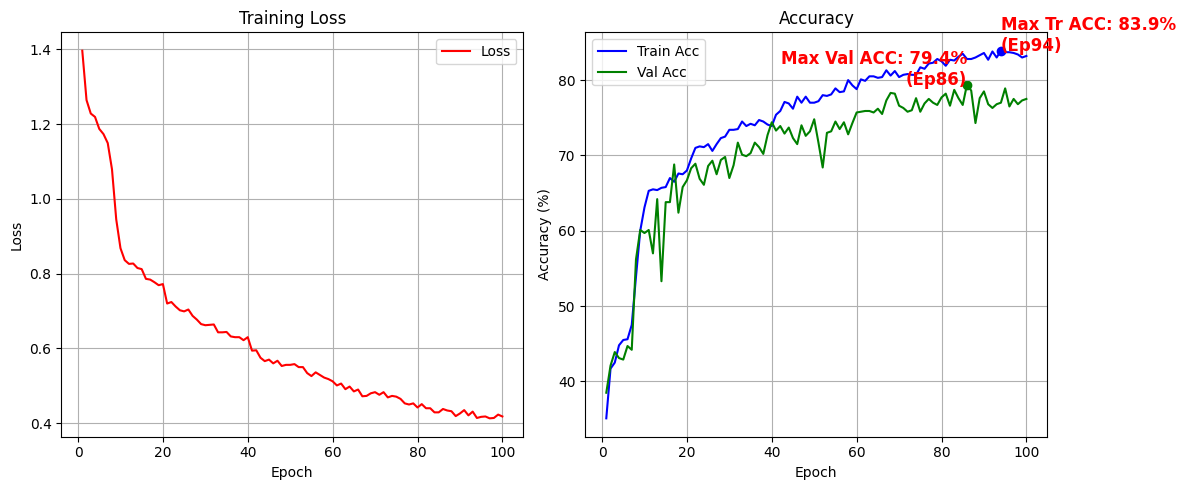

In [15]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import os

# 경로 설정
LOG_PATH = "../../checkpoints/record_train.txt"
CSV_PATH = "training_log.csv"

data = []
# 정규표현식: [Ep 숫자] Loss:숫자 | Tr_Acc:숫자% | Val_Acc:숫자%
pattern = re.compile(r"\[Ep (\d+)\] Loss:([\d\.]+) \| Tr_Acc:([\d\.]+)% \| Val_Acc:([\d\.]+)%")

if not os.path.exists(LOG_PATH):
    print(f"Error: Log file not found at {LOG_PATH}")
    print(f"Current CWD: {os.getcwd()}")
else:
    with open(LOG_PATH, 'r') as f:
        for line in f:
            match = pattern.search(line)
            if match:
                data.append({
                    "Epoch": int(match.group(1)),
                    "Loss": float(match.group(2)),
                    "Train_Acc": float(match.group(3)),
                    "Val_Acc": float(match.group(4))
                })

if data:
    df = pd.DataFrame(data)
    df.to_csv(CSV_PATH, index=False)
    print(f"Saved CSV to {CSV_PATH}")
    
    # Max Calculation
    max_train_idx = df['Train_Acc'].idxmax()
    max_val_idx = df['Val_Acc'].idxmax()
    max_train_row = df.loc[max_train_idx]
    max_val_row = df.loc[max_val_idx]
    
    print(f"Max Train Acc: {max_train_row['Train_Acc']}% at Epoch {int(max_train_row['Epoch'])}")
    print(f"Max Val Acc: {max_val_row['Val_Acc']}% at Epoch {int(max_val_row['Epoch'])}")

    # Plotting
    plt.figure(figsize=(12, 5))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(df['Epoch'], df['Loss'], label='Loss', color='red')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(df['Epoch'], df['Train_Acc'], label='Train Acc', color='blue')
    plt.plot(df['Epoch'], df['Val_Acc'], label='Val Acc', color='green')
    
    # Max Text Annotations
    plt.scatter(max_train_row['Epoch'], max_train_row['Train_Acc'], color='blue')
    plt.text(max_train_row['Epoch'], max_train_row['Train_Acc'], 
             f"Max Tr ACC: {max_train_row['Train_Acc']}%\n(Ep{int(max_train_row['Epoch'])})", 
             fontsize=12, fontweight='bold', color='red', ha='left')

    plt.scatter(max_val_row['Epoch'], max_val_row['Val_Acc'], color='green')
    plt.text(max_val_row['Epoch'], max_val_row['Val_Acc'], 
             f"Max Val ACC: {max_val_row['Val_Acc']}%\n(Ep{int(max_val_row['Epoch'])})", 
             fontsize=12, fontweight='bold', color='red',ha='right')

    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("No data found matching the pattern.")